In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Part 1: Data Exploration

In [3]:
# 1. Load the dataset and review its structure.
df = pd.read_csv('Employee.csv')


In [7]:
# 2. Identify the categorical and numerical features.

numerical_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain', 'LeaveOrNot']
Categorical Features: ['Education', 'City', 'Gender', 'EverBenched']


In [9]:
# 3. Check for missing values.
df.isna()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
4648,False,False,False,False,False,False,False,False,False
4649,False,False,False,False,False,False,False,False,False
4650,False,False,False,False,False,False,False,False,False
4651,False,False,False,False,False,False,False,False,False


In [24]:
# 4. Compute summary statistics for numerical features (Age, PaymentTier, ExperienceInCurrentDomain).

age_summary = {
    'Mean': df['Age'].mean(),
    'Median': df['Age'].median(),
    'Mode': df['Age'].mode().tolist(),
    'Std': df['Age'].std(),
    'Min': df['Age'].min(),
    'Q1': df['Age'].quantile(0.25),
    'Q2': df['Age'].quantile(0.50),
    'Q3': df['Age'].quantile(0.75),
    'Max': df['Age'].max()
}

paymentTier_summary = {
    'Mean': df['PaymentTier'].mean(),
    'Median': df['PaymentTier'].median(),
    'Mode': df['PaymentTier'].mode().tolist(),
    'Std': df['PaymentTier'].std(),
    'Min': df['PaymentTier'].min(),
    'Q1': df['PaymentTier'].quantile(0.25),
    'Q2': df['PaymentTier'].quantile(0.50),
    'Q3': df['PaymentTier'].quantile(0.75),
    'Max': df['PaymentTier'].max()
}

experienceInCurrentDomain_summary = {
    'Mean': df['ExperienceInCurrentDomain'].mean(),
    'Median': df['ExperienceInCurrentDomain'].median(),
    'Mode': df['ExperienceInCurrentDomain'].mode().tolist(),
    'Std': df['ExperienceInCurrentDomain'].std(),
    'Min': df['ExperienceInCurrentDomain'].min(),
    'Q1': df['ExperienceInCurrentDomain'].quantile(0.25),
    'Q2': df['ExperienceInCurrentDomain'].quantile(0.50),
    'Q3': df['ExperienceInCurrentDomain'].quantile(0.75),
    'Max': df['ExperienceInCurrentDomain'].max()
}

print("Age Summary:\n", age_summary)
print("-"*100)
print("PaymentTier Summary:\n", paymentTier_summary)
print("-"*100)
print("ExperienceInCurrentDomain Summary:\n", experienceInCurrentDomain_summary)


Age Summary:
 {'Mean': np.float64(29.393294648613796), 'Median': 28.0, 'Mode': [26], 'Std': 4.826087009126047, 'Min': 22, 'Q1': np.float64(26.0), 'Q2': np.float64(28.0), 'Q3': np.float64(32.0), 'Max': 41}
----------------------------------------------------------------------------------------------------
PaymentTier Summary:
 {'Mean': np.float64(2.6982591876208897), 'Median': 3.0, 'Mode': [3], 'Std': 0.5614354643365063, 'Min': 1, 'Q1': np.float64(3.0), 'Q2': np.float64(3.0), 'Q3': np.float64(3.0), 'Max': 3}
----------------------------------------------------------------------------------------------------
ExperienceInCurrentDomain Summary:
 {'Mean': np.float64(2.905652267354395), 'Median': 3.0, 'Mode': [2], 'Std': 1.5582403309268553, 'Min': 0, 'Q1': np.float64(2.0), 'Q2': np.float64(3.0), 'Q3': np.float64(4.0), 'Max': 7}


In [27]:
# 4. Compute summary statistics for numerical features (Age, PaymentTier, ExperienceInCurrentDomain).
# NOTE: Another way

print("Age Summary:\n", df['Age'].describe())
print("-"*100)
print("PaymentTier Summary:\n", df['PaymentTier'].describe())
print("-"*100)
print("ExperienceInCurrentDomain Summary:\n", df['ExperienceInCurrentDomain'].describe())



Age Summary:
 count    4653.000000
mean       29.393295
std         4.826087
min        22.000000
25%        26.000000
50%        28.000000
75%        32.000000
max        41.000000
Name: Age, dtype: float64
----------------------------------------------------------------------------------------------------
PaymentTier Summary:
 count    4653.000000
mean        2.698259
std         0.561435
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         3.000000
Name: PaymentTier, dtype: float64
----------------------------------------------------------------------------------------------------
ExperienceInCurrentDomain Summary:
 count    4653.000000
mean        2.905652
std         1.558240
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: ExperienceInCurrentDomain, dtype: float64


In [31]:
# 5. Analyze the distribution of categorical features (Education, City, Gender, EverBenched).

print("Education Distribution:\n",df['Education'].value_counts())
print("-"*100)
print("City Distribution:\n",df['City'].value_counts())
print("-"*100)
print("Gender Distribution:\n",df['Gender'].value_counts())
print("-"*100)
print("EverBenched Distribution:\n",df['EverBenched'].value_counts())

Education Distribution:
 Education
Bachelors    3601
Masters       873
PHD           179
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
City Distribution:
 City
Bangalore    2228
Pune         1268
New Delhi    1157
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Gender Distribution:
 Gender
Male      2778
Female    1875
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
EverBenched Distribution:
 EverBenched
No     4175
Yes     478
Name: count, dtype: int64


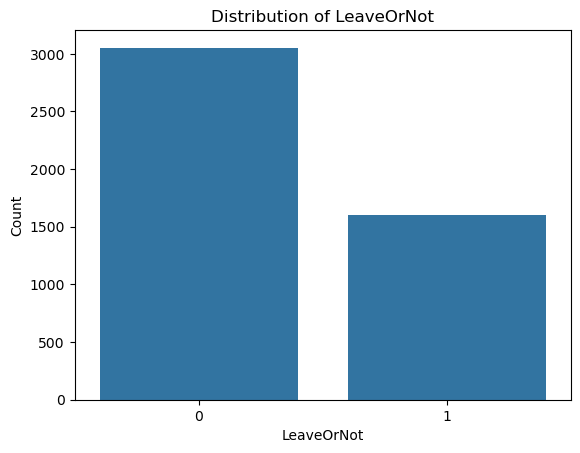

In [34]:
# 6. Plot or visualize the distribution of the target variable LeaveOrNot.

sns.countplot(x='LeaveOrNot', data=df)

plt.title('Distribution of LeaveOrNot')
plt.xlabel('LeaveOrNot')
plt.ylabel('Count')
plt.show()

Part 2: Data Preprocessing

In [36]:
# 1. Encode categorical features (Education, City, Gender, EverBenched) appropriately.

df_encoded = pd.get_dummies(df, columns=['Education', 'City', 'Gender', 'EverBenched'], drop_first=True)
print(df_encoded.head())

   JoiningYear  PaymentTier  Age  ExperienceInCurrentDomain  LeaveOrNot  \
0         2017            3   34                          0           0   
1         2013            1   28                          3           1   
2         2014            3   38                          2           0   
3         2016            3   27                          5           1   
4         2017            3   24                          2           1   

   Education_Masters  Education_PHD  City_New Delhi  City_Pune  Gender_Male  \
0              False          False           False      False         True   
1              False          False           False       True        False   
2              False          False            True      False        False   
3               True          False           False      False         True   
4               True          False           False       True         True   

   EverBenched_Yes  
0            False  
1            False  
2          

In [45]:
# 2. Handle scaling of numerical features if needed (Age, ExperienceInCurrentDomain, JoiningYear, PaymentTier).

scaler = StandardScaler()
num_cols = ['Age', 'ExperienceInCurrentDomain', 'JoiningYear', 'PaymentTier']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
print(df[num_cols].head())

        Age  ExperienceInCurrentDomain  JoiningYear  PaymentTier
0  0.954645                  -1.864901     1.039638     0.537503
1 -0.288732                   0.060554    -1.107233    -3.025177
2  1.783563                  -0.581264    -0.570515     0.537503
3 -0.495961                   1.344191     0.502921     0.537503
4 -1.117650                  -0.581264     1.039638     0.537503


In [46]:
# 3. Split the dataset into training and testing sets (suggested: 80%-20%).

x = df_encoded.drop('LeaveOrNot', axis=1)
y = df_encoded['LeaveOrNot']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training set:", x_train.shape)
print("Testing set:", x_test.shape)

Training set: (3722, 10)
Testing set: (931, 10)


Part 3: Model Building
Train at least two classification models:

In [57]:
# 1. Decision Tree Classifier
#     o Use this model to predict LeaveOrNot.

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8388829215896885
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       610
           1       0.79      0.73      0.76       321

    accuracy                           0.84       931
   macro avg       0.83      0.81      0.82       931
weighted avg       0.84      0.84      0.84       931



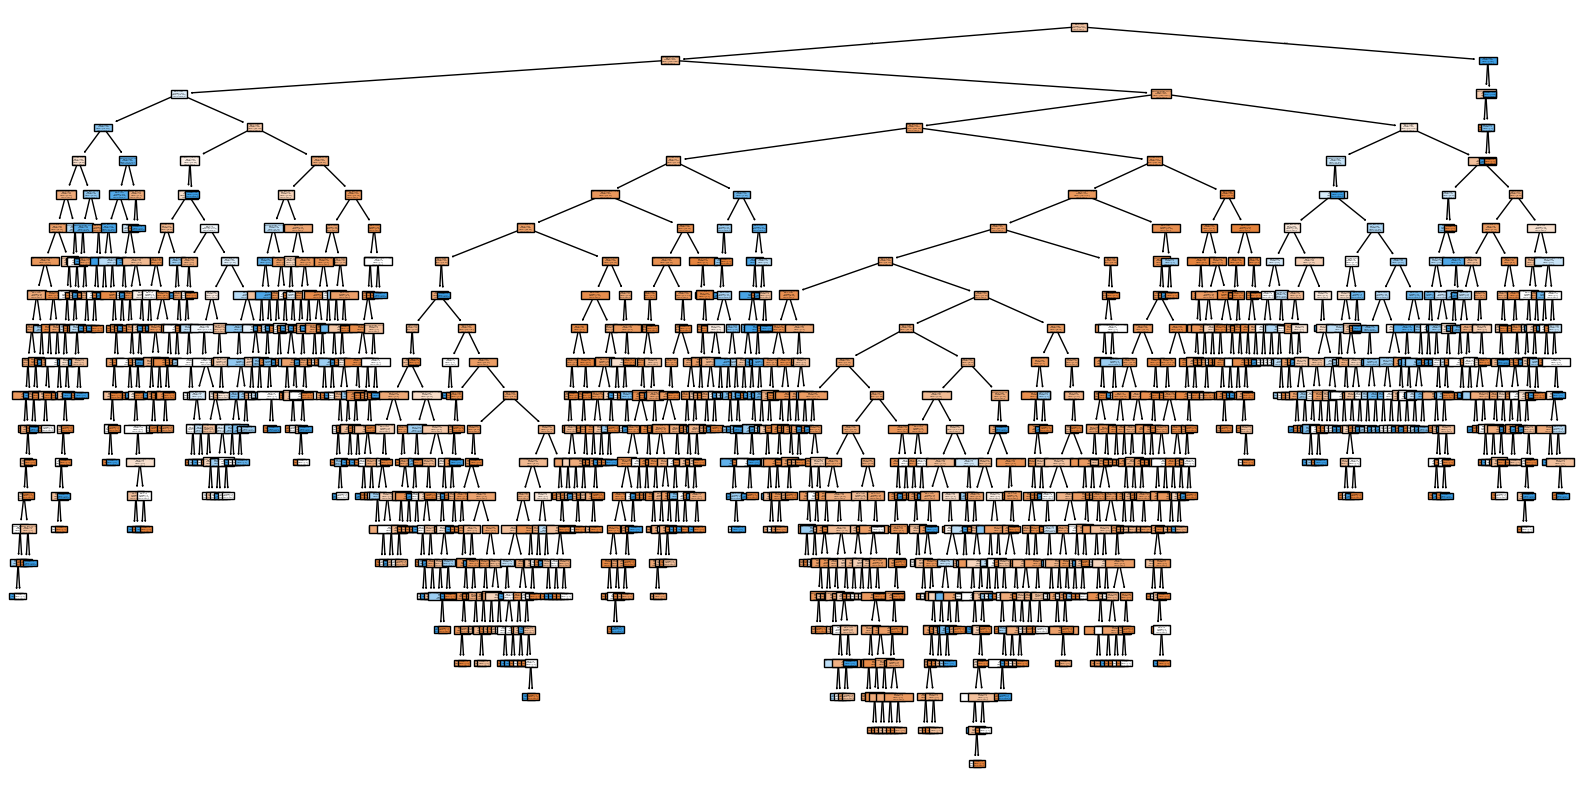

In [54]:
#     o Interpret the tree and understand the splits.

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=x.columns,
    class_names=['Stay (0)', 'Leave (1)'],
    filled=True
)

plt.show()

In [55]:
# 2. Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)


print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8517722878625135
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       610
           1       0.82      0.73      0.77       321

    accuracy                           0.85       931
   macro avg       0.84      0.82      0.83       931
weighted avg       0.85      0.85      0.85       931



In [58]:
#     o Train a Random Forest and compare with Decision Tree.
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 0.8388829215896885
Random Forest Accuracy: 0.8517722878625135


Part 4: Model Evaluation

In [60]:
# 1. Predict the target variable on the test set.
y_pred_dt = dt_model.predict(x_test)
print(y_pred_dt[:10])

[0 0 0 0 0 0 0 1 0 1]


In [62]:
# 2. Compute evaluation metrics: accuracy.

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Decision Tree Accuracy: 0.8388829215896885
Random Forest Accuracy: 0.8517722878625135


Part 5: Analysis Questions

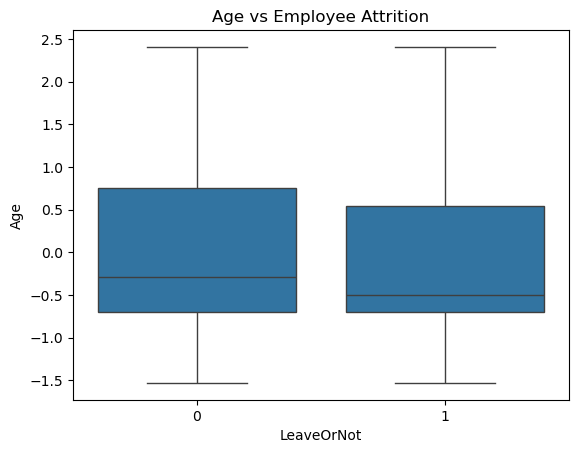

In [65]:
# 2. How do Age and ExperienceInCurrentDomain affect the likelihood of leaving?
# Answer: Younger employees explors new job opportunities for better salary and skill development. Older employees prefer job security.

sns.boxplot(x='LeaveOrNot', y='Age', data=df)
plt.title("Age vs Employee Attrition")
plt.show()

In [66]:
# 3. Compare Decision Tree and Random Forest results. Which model performs better and why?
# Answer: Usually, Random Forest performs better than a Decision Tree because it combines 
# multiple trees and reduces overfitting. This gives us more accurate and stable predictions on unseen data.

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 0.8388829215896885
Random Forest Accuracy: 0.8517722878625135


4. Suggest HR strategies based on your analysis.
Answer:
1. Review and adjust salary bands regularly
2. Introduce performance-based bonuses
3. Offer retention bonuses for high-risk employees